# ResNet18 student model

This is a student detector for the SIXray-D project.

labels are numbered:

- 0 = gun
- 1 = knife
- 2 = wrench
- 3 = pliers
- 4 = scissors


In [1]:
!pip install -q torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.0 MB/s eta 0:00:00


In [2]:

from google.colab import userdata
import wandb

wandb.login(key=userdata.get("WANDB_API_KEY"))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: anna_smetanina (anna_smetanina-university-of-verona) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

!git clone -b angelo https://github.com/angelo4o4/sixray-kd.git /content/sixray-kd

import sys
sys.path.append('/content/sixray-kd')

Mounted at /content/drive
Cloning into '/content/sixray-kd'...
remote: Enumerating objects: 179, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 179 (delta 84), reused 122 (delta 33), pack-reused 0 (from 0)
Receiving objects: 100% (179/179), 5.24 MiB | 9.21 MiB/s, done.
Resolving deltas: 100% (84/84), done.


In [4]:
!bash /content/sixray-kd/scripts/setup_colab.sh
!pip install -q wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.2 MB/s eta 0:00:00
Dataset 'subset_clean.zip' extracted to /content/data


In [5]:
from pathlib import Path

DATA_ROOT = Path("/content/data/")

TRAIN_IMG_DIR = DATA_ROOT / "train" / "images"
TRAIN_JSON = DATA_ROOT / "train.json"
TEST_IMG_DIR = DATA_ROOT / "test" / "images"
TEST_JSON = DATA_ROOT / "test.json"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("TRAIN_JSON:", TRAIN_JSON)
print("TEST_IMG_DIR:", TEST_IMG_DIR)
print("TEST_JSON:", TEST_JSON)

assert TRAIN_IMG_DIR.exists()
assert TRAIN_JSON.exists()
assert TEST_IMG_DIR.exists()
assert TEST_JSON.exists()

DATA_ROOT: /content/data
TRAIN_IMG_DIR: /content/data/train/images
TRAIN_JSON: /content/data/train.json
TEST_IMG_DIR: /content/data/test/images
TEST_JSON: /content/data/test.json


In [6]:
import torch

print(f"PyTorch version: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is not available. Training this model on CPU will be very slow.")


PyTorch version: 2.11.0+cu128
Using device: cuda
GPU: Tesla T4


In [7]:
import json
import random
import numpy as np
import torch
from pathlib import Path

SEED=42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [8]:
import json
from pathlib import Path

SPLIT_PATH = Path("/content/drive/MyDrive/DatasetAPAI/SIXray_Project/splits/split_seed42_train10500_val300pos1200neg.json")

with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    split_info = json.load(f)

train_indices = split_info["train_indices"]
val_indices = split_info["val_indices"]
test_indices = split_info["test_indices"]

CLASS_NAMES = ["gun", "knife", "wrench", "pliers", "scissors"]
NUM_CLASSES = len(CLASS_NAMES)
id2label = {i: name for i, name in enumerate(CLASS_NAMES)}
label2id = {name: i for i, name in enumerate(CLASS_NAMES)}

print("Loaded split")
print("Train:", len(train_indices))
print("Val:", len(val_indices))
print("Test:", len(test_indices))
print("Classes:", id2label)

Loaded split
Train: 10500
Val: 1500
Test: 13246
Classes: {0: 'gun', 1: 'knife', 2: 'wrench', 3: 'pliers', 4: 'scissors'}


Dataset

In [9]:
import json
from pathlib import Path
from collections import defaultdict

import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision.transforms import functional as TF


class SixRayStudentDataset(Dataset):
    def __init__(self, images_dir, annotation_file, indices, image_size=640):
        self.images_dir = Path(images_dir)
        self.annotation_file = Path(annotation_file)
        self.indices = list(indices)
        self.image_size = image_size

        with open(self.annotation_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        self.images = data["images"]
        self.annotations = data["annotations"]

        #annotations grouped by image id, so __getitem__ is faster.
        self.annotations_by_image_id = defaultdict(list)
        for ann in self.annotations:
            self.annotations_by_image_id[ann["image_id"]].append(ann)

        print("Dataset:", self.annotation_file)
        print("Images folder:", self.images_dir)
        print("Images used here:", len(self.indices))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, dataset_index):
        real_index = self.indices[dataset_index]
        image_info = self.images[real_index]
        image_id = image_info["id"]
        file_name = image_info["file_name"]
        image_path = self.images_dir / file_name
        image = Image.open(image_path).convert("RGB")

        old_width, old_height = image.size
        image = image.resize((self.image_size, self.image_size))
        image_tensor = TF.to_tensor(image)

        scale_x = self.image_size / old_width
        scale_y = self.image_size / old_height
        boxes = []
        labels = []

        for ann in self.annotations_by_image_id.get(image_id, []):
            x, y, w, h = ann["bbox"]
            x1 = float(x) * scale_x
            y1 = float(y) * scale_y
            x2 = float(x + w) * scale_x
            y2 = float(y + h) * scale_y

            x1 = max(0.0, min(x1, self.image_size))
            y1 = max(0.0, min(y1, self.image_size))
            x2 = max(0.0, min(x2, self.image_size))
            y2 = max(0.0, min(y2, self.image_size))
            label = int(ann["category_id"])

            if x2 > x1 and y2 > y1:
              boxes.append([x1, y1, x2, y2])
              labels.append(label)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        image_id = torch.tensor([int(image_id)], dtype=torch.int64)

        target = {
            "boxes": boxes, # tensor [N, 4], float32
            "labels": labels, # tensor [N], float64
            "image_id": image_id, # tensor [N], float64
        }

        return image_tensor, target

In [10]:
train_dataset = SixRayStudentDataset(
    images_dir=TRAIN_IMG_DIR,
    annotation_file=TRAIN_JSON,
    indices=train_indices,
    image_size=640,
)

val_dataset = SixRayStudentDataset(
    images_dir=TRAIN_IMG_DIR,
    annotation_file=TRAIN_JSON,
    indices=val_indices,
    image_size=640,
)

test_dataset = SixRayStudentDataset(
    images_dir=TEST_IMG_DIR,
    annotation_file=TEST_JSON,
    indices=test_indices,
    image_size=640,
)

Dataset: /content/data/train.json
Images folder: /content/data/train/images
Images used here: 10500
Dataset: /content/data/train.json
Images folder: /content/data/train/images
Images used here: 1500
Dataset: /content/data/test.json
Images folder: /content/data/test/images
Images used here: 13246


Dataloaders

In [11]:
def detection_collate_fn(batch):
    images = []
    targets = []

    for image, target in batch:
        images.append(image)
        targets.append(target)
    images = torch.stack(images, dim=0)
    return images, targets

In [12]:
from torch.utils.data import DataLoader
import torch

BATCH_SIZE = 2
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate_fn,
    pin_memory=torch.cuda.is_available(),
)

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def get_class_name(label_id):
    return id2label.get(int(label_id), f"class_{int(label_id)}")


def visualize_detection_sample(dataset, dataset_index, title_prefix="Sample"):
    image_tensor, target = dataset[dataset_index]
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    boxes = target["boxes"].cpu()
    labels = target["labels"].cpu()
    image_id = int(target["image_id"].item())

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(image_np)

    if len(boxes) == 0:
        ax.set_title(f"{title_prefix} | index={dataset_index} | image_id={image_id} | negative")
        ax.axis("off")
        plt.show()
        return

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist()

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)

        ax.text(
            x1,
            max(y1 - 5, 0),
            get_class_name(label.item()),
            fontsize=9,
            color="white",
            bbox=dict(facecolor="red", alpha=0.7),
        )

    ax.set_title(f"{title_prefix} | index={dataset_index} | image_id={image_id}")
    ax.axis("off")
    plt.show()

In [14]:
def find_first_positive_indices(dataset, n=5):
    positive_indices = []

    for i in range(len(dataset)):
        _, target = dataset[i]
        if len(target["boxes"]) > 0:
            positive_indices.append(i)

        if len(positive_indices) >= n:
            break

    return positive_indices


def find_first_negative_indices(dataset, n=5):
    negative_indices = []

    for i in range(len(dataset)):
        _, target = dataset[i]
        if len(target["boxes"]) == 0:
            negative_indices.append(i)

        if len(negative_indices) >= n:
            break

    return negative_indices


positive_train_indices = find_first_positive_indices(train_dataset, n=5)
negative_train_indices = find_first_negative_indices(train_dataset, n=5)

print("First positive indices in train_dataset:", positive_train_indices)
print("First negative indices in train_dataset:", negative_train_indices)

First positive indices in train_dataset: [0, 3, 4, 5, 6]
First negative indices in train_dataset: [1, 2, 7, 8, 9]


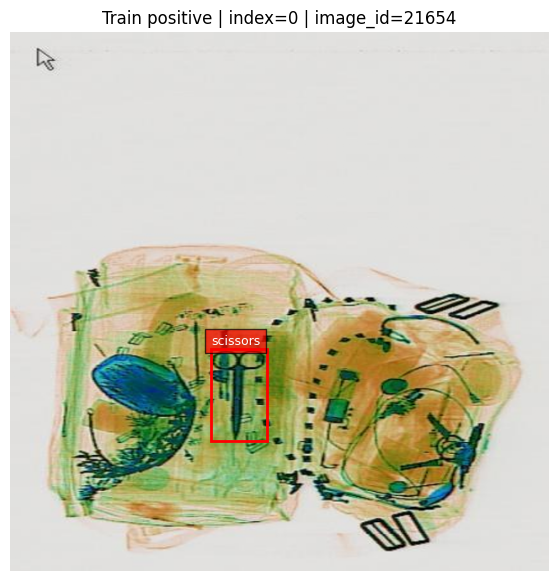

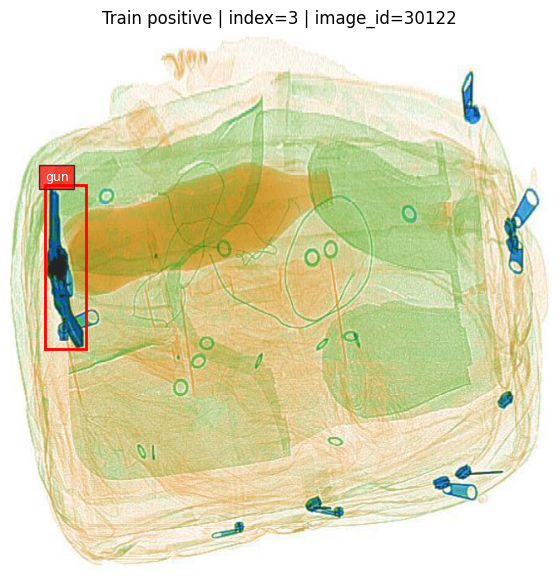

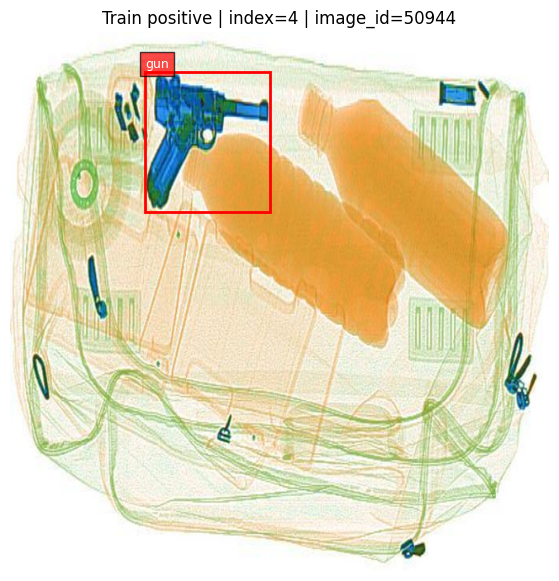

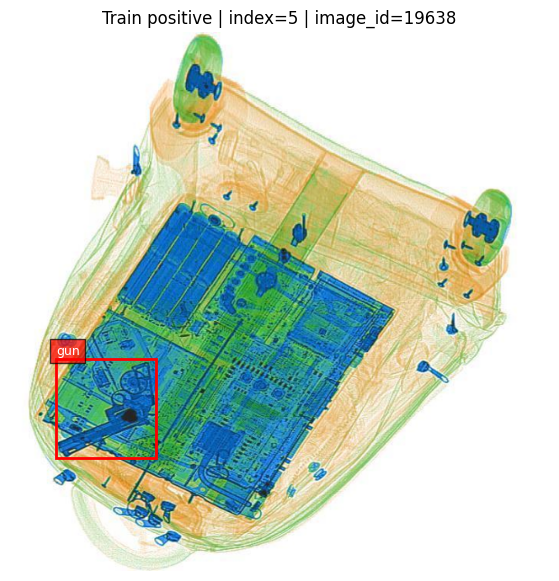

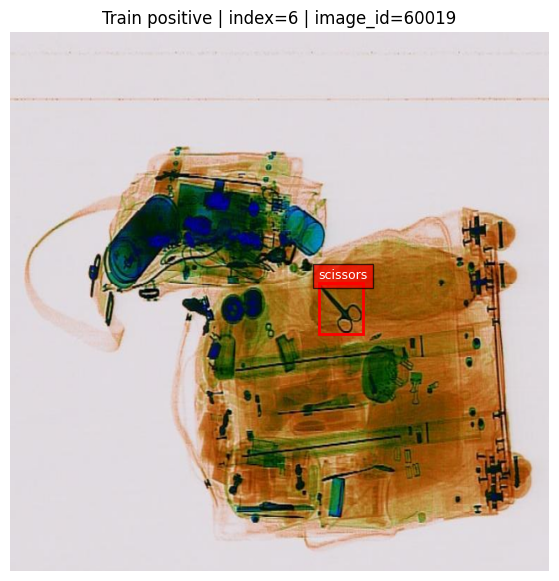

In [15]:
for idx in positive_train_indices:
    visualize_detection_sample(
        dataset=train_dataset,
        dataset_index=idx,
        title_prefix="Train positive",
    )

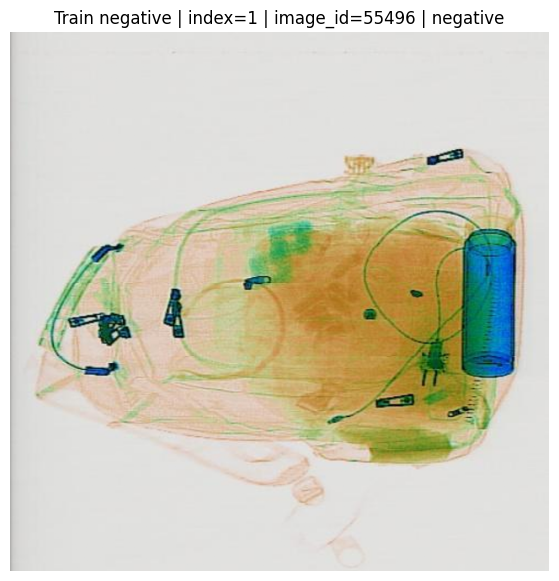

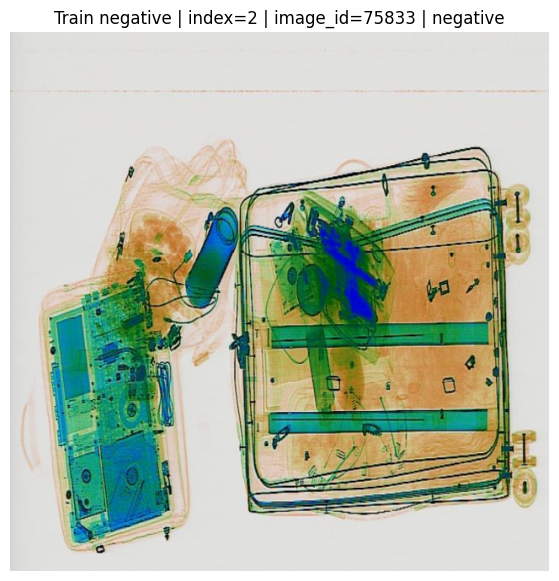

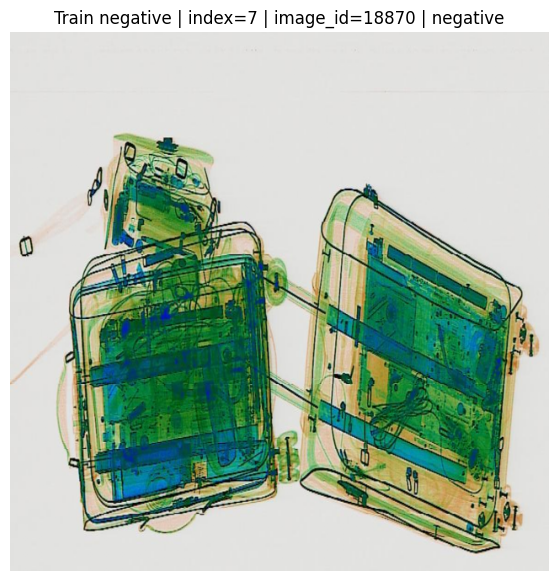

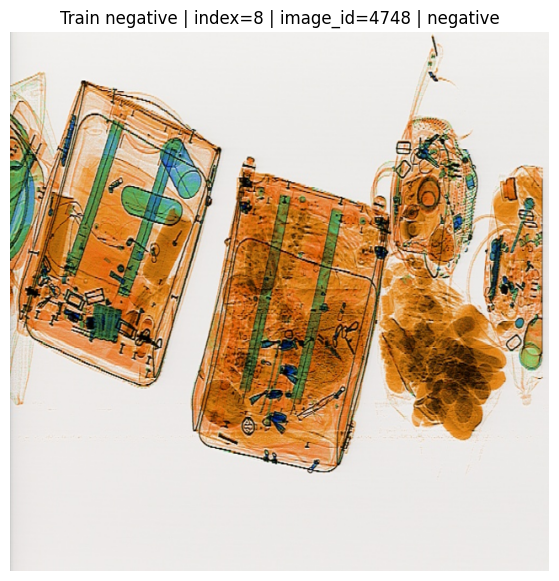

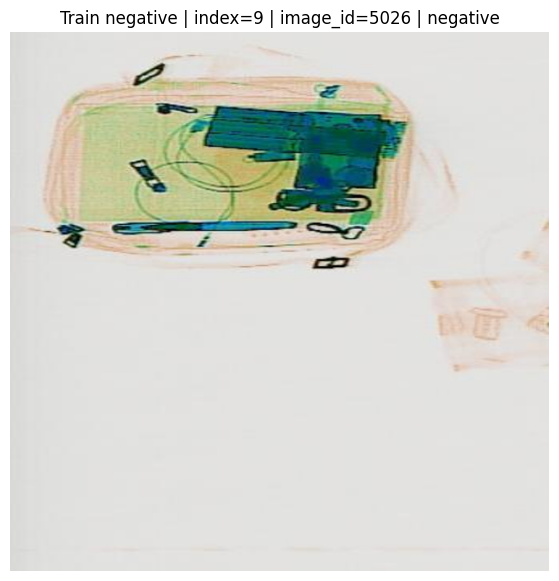

In [16]:
for idx in negative_train_indices:
    visualize_detection_sample(
        dataset=train_dataset,
        dataset_index=idx,
        title_prefix="Train negative",
    )

In [17]:
images, targets = next(iter(train_loader))

print("Batch size:", len(images))
print("First image shape:", images[0].shape)
print("First image min/max:", images[0].min().item(), images[0].max().item())

print("\nFirst target:")
for key, value in targets[0].items():
    print(key, value.shape, value.dtype)

print("\nFirst target labels:", targets[0]["labels"])
print("First target boxes:", targets[0]["boxes"][:5])

Batch size: 2
First image shape: torch.Size([3, 640, 640])
First image min/max: 0.0 1.0

First target:
boxes torch.Size([0, 4]) torch.float32
labels torch.Size([0]) torch.int64
image_id torch.Size([1]) torch.int64

First target labels: tensor([], dtype=torch.int64)
First target boxes: tensor([], size=(0, 4))


Student model

The model is a simple single-stage object detector:

- input image: `[3, 640, 640]`
- ResNet18 backbone
- prediction grid: `20 x 20`
- prediction per grid cell: two possible boxes per grid cell
- five classes

So the final output has:

```python
2 * (1 + 4 + 5) = 20
```

channels.

In [18]:
from torchvision.models import resnet18, ResNet18_Weights

resnet = resnet18(weights=ResNet18_Weights.DEFAULT)

print("ResNet18 children:")
for name, module in resnet.named_children():
    print(name, "->", module.__class__.__name__)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


ResNet18 children:
conv1 -> Conv2d
bn1 -> BatchNorm2d
relu -> ReLU
maxpool -> MaxPool2d
layer1 -> Sequential
layer2 -> Sequential
layer3 -> Sequential
layer4 -> Sequential
avgpool -> AdaptiveAvgPool2d
fc -> Linear


In [19]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


class ImageNetNormalize(nn.Module):
    def __init__(self):
        super().__init__()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, images):
        return (images - self.mean) / self.std

In [20]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


IMAGE_SIZE = 640
GRID_SIZE = 20
NUM_CLASSES = 5
NUM_BOXES = 2
HEAD_CHANNELS = 256


class ResNet18Backbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        resnet = resnet18(weights=weights)

        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        return x


class ResNet18YOLOStudent(nn.Module):
    """
    ResNet18 single stage student detector.
    Input:
        images: [B, 3, 640, 640], values in [0, 1]
    Output:
        predictions: [B, NUM_BOXES * (1 + 4 + NUM_CLASSES), 20, 20]
    For each grid cell and each box slot:
        1 objectness logit
        4 bbox raw values for [tx, ty, w, h]
        where tx, ty are local offsets inside the grid cell and w, h are normalized width, heikgth
        NUM_CLASSES class logits
    """
    def __init__(
        self,
        head_channels=HEAD_CHANNELS,
        num_classes=NUM_CLASSES,
        num_boxes=NUM_BOXES,
        pretrained_backbone=True,
    ):
        super().__init__()

        self.num_classes = int(num_classes)
        self.num_boxes = int(num_boxes)
        self.values_per_box = 1 + 4 + self.num_classes

        self.backbone = ResNet18Backbone(pretrained=pretrained_backbone)
        self.normalizer = ImageNetNormalize()

        out_channels = self.num_boxes * self.values_per_box

        self.head = nn.Sequential(
            nn.Conv2d(512, head_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(head_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(head_channels, head_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(head_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(head_channels, out_channels, kernel_size=1),
        )

    def forward(self, images):
        images = self.normalizer(images)
        features = self.backbone(images)
        predictions = self.head(features)
        return predictions


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def count_total_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet18YOLOStudent(
    num_classes=NUM_CLASSES,
    num_boxes=NUM_BOXES,
    head_channels=HEAD_CHANNELS,
    pretrained_backbone=True,
).to(device)

model.eval()

expected_channels = NUM_BOXES * (1 + 4 + NUM_CLASSES)
dummy_images = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)

with torch.no_grad():
    predictions = model(dummy_images)

print("Dummy images:", dummy_images.shape)
print("Predictions:", predictions.shape)
print("Expected channels:", expected_channels)
print("Total parameters:", count_total_parameters(model))
print("Trainable parameters:", count_trainable_parameters(model))

assert predictions.shape == (2, expected_channels, GRID_SIZE, GRID_SIZE)


Dummy images: torch.Size([2, 3, 640, 640])
Predictions: torch.Size([2, 20, 20, 20])
Expected channels: 20
Total parameters: 12952660
Trainable parameters: 12952660


In [22]:
model.eval()

images, targets = next(iter(train_loader))

print("Images before device:", images.shape)
print("Image min:", images.min().item())
print("Image max:", images.max().item())
print("Number of targets:", len(targets))
images = images.to(device)

with torch.no_grad():
    predictions = model(images)

print("Predictions:", predictions.shape)
assert images.shape[1:] == (3, 640, 640)
assert predictions.shape[1:] == (20, GRID_SIZE, GRID_SIZE)

print("target: ")
for key, value in targets[0].items():
    print(key, value.shape, value.dtype)

Images before device: torch.Size([2, 3, 640, 640])
Image min: 0.0
Image max: 1.0
Number of targets: 2
Predictions: torch.Size([2, 20, 20, 20])
target: 
boxes torch.Size([1, 4]) torch.float32
labels torch.Size([1]) torch.int64
image_id torch.Size([1]) torch.int64


In [23]:
target = targets[0]
boxes = target["boxes"]
labels = target["labels"]

for i in range(boxes.shape[0]):
    x1, y1, x2, y2 = boxes[i]
    label_id = int(labels[i].item())
    print(f"Object {i}: {get_class_name(label_id)}")
    print(f"  box: [{x1.item():.2f}, {y1.item():.2f}, {x2.item():.2f}, {y2.item():.2f}]")

Object 0: gun
  box: [201.94, 257.16, 362.53, 351.42]


Target encoder

convert normal boxes into the grid format used by the model.

In [24]:
import torch


def encode_targets_yolo(
    targets,
    image_size=IMAGE_SIZE,
    grid_size=GRID_SIZE,
    num_classes=NUM_CLASSES,
    num_boxes=NUM_BOXES,
    device=None
):
    B = len(targets)
    S = grid_size
    K = num_boxes

    objectness = torch.zeros((B, K, 1, S, S), device=device)
    bbox = torch.zeros((B, K, 4, S, S), device=device)
    classes = -torch.ones((B, K, S, S), dtype=torch.long, device=device)
    positive_mask = torch.zeros((B, K, 1, S, S), device=device)

    assigned_objects = 0
    skipped_invalid_boxes = 0
    skipped_collisions = 0

    for b in range(B):
        boxes = targets[b]["boxes"].cpu()
        labels = targets[b]["labels"].cpu()

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box.tolist()
            label = int(label)

            w = x2 - x1
            h = y2 - y1

            if w <= 0 or h <= 0:
                skipped_invalid_boxes += 1
                continue

            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            cx_norm = cx / image_size
            cy_norm = cy / image_size
            w_norm = w / image_size
            h_norm = h / image_size

            grid_x = int(cx_norm * S)
            grid_y = int(cy_norm * S)

            grid_x = max(0, min(grid_x, S - 1))
            grid_y = max(0, min(grid_y, S - 1))

            local_x = cx_norm * S - grid_x
            local_y = cy_norm * S - grid_y

            slot = -1 # number of boxes in grid cell

            for k in range(K):
                if positive_mask[b, k, 0, grid_y, grid_x] == 0:
                    slot = k
                    break

            if slot == -1: # if there are already all slots for cell assigned, count as collision
                skipped_collisions += 1
                continue

            objectness[b, slot, 0, grid_y, grid_x] = 1.0
            positive_mask[b, slot, 0, grid_y, grid_x] = 1.0

            bbox[b, slot, 0, grid_y, grid_x] = local_x
            bbox[b, slot, 1, grid_y, grid_x] = local_y
            bbox[b, slot, 2, grid_y, grid_x] = w_norm
            bbox[b, slot, 3, grid_y, grid_x] = h_norm

            classes[b, slot, grid_y, grid_x] = label

            assigned_objects += 1

    return {
        "objectness": objectness,
        "bbox": bbox,
        "classes": classes,
        "positive_mask": positive_mask,
        "assigned_objects": assigned_objects,
        "skipped_invalid_boxes": skipped_invalid_boxes,
        "skipped_collisions": skipped_collisions,
    }

In [25]:
images, targets = next(iter(train_loader))
images = images.to(device)

encoded = encode_targets_yolo(
    targets=targets,
    image_size=IMAGE_SIZE,
    grid_size=GRID_SIZE,
    num_classes=NUM_CLASSES,
    num_boxes=NUM_BOXES,
    device=device,
)

print("objectness:", encoded["objectness"].shape)
print("bbox:", encoded["bbox"].shape)
print("classes:", encoded["classes"].shape)
print("positive slots:", encoded["positive_mask"].sum().item())
print("assigned objects:", encoded["assigned_objects"])
print("skipped invalid boxes:", encoded["skipped_invalid_boxes"])
print("skipped collisions:", encoded["skipped_collisions"])

positive_labels = encoded["classes"][encoded["classes"] >= 0]
print("class labels in positive slots:")
print(positive_labels)


objectness: torch.Size([2, 2, 1, 20, 20])
bbox: torch.Size([2, 2, 4, 20, 20])
classes: torch.Size([2, 2, 20, 20])
positive slots: 2.0
assigned objects: 2
skipped invalid boxes: 0
skipped collisions: 0
class labels in positive slots:
tensor([1, 4], device='cuda:0')


In [26]:
def count_grid_collisions(data_loader, image_size=IMAGE_SIZE, grid_size=GRID_SIZE, num_boxes=NUM_BOXES, max_batches=50):
    S = int(grid_size)
    K = int(num_boxes)

    total_objects = 0
    assigned_objects = 0
    skipped_due_to_collision = 0

    for batch_idx, (images, targets) in enumerate(data_loader):
        if batch_idx >= max_batches:
            break

        for target in targets:
            cell_counts = {}
            boxes = target["boxes"]

            for box in boxes:
                x1, y1, x2, y2 = box

                w = x2 - x1
                h = y2 - y1

                if w <= 0 or h <= 0:
                    continue

                cx = (x1 + x2) / 2
                cy = (y1 + y2) / 2

                gx = int(cx / image_size * S)
                gy = int(cy / image_size * S)

                gx = max(0, min(gx, S - 1))
                gy = max(0, min(gy, S - 1))

                total_objects += 1
                cell = (gy, gx)
                cell_counts[cell] = cell_counts.get(cell, 0) + 1

                if cell_counts[cell] <= K:
                    assigned_objects += 1
                else:
                    skipped_due_to_collision += 1

    print("Total objects:", total_objects)
    print("Assigned objects:", assigned_objects)
    print(f"Skipped because more than {K} objects fell into the same cell:", skipped_due_to_collision)

    if total_objects > 0:
        collision_rate = skipped_due_to_collision / total_objects
        print(f"Collision rate after allowing {K} slot(s) per cell: {collision_rate:.4f}")


In [27]:
count_grid_collisions(
    data_loader=train_loader,
    image_size=IMAGE_SIZE,
    grid_size=GRID_SIZE,
    num_boxes=NUM_BOXES,
    max_batches=100,
)


Total objects: 248
Assigned objects: 248
Skipped because more than 2 objects fell into the same cell: 0
Collision rate after allowing 2 slot(s) per cell: 0.0000


Loss

In [28]:
def split_predictions(predictions, num_classes=NUM_CLASSES, num_boxes=NUM_BOXES):
    """
    predictions: [B, K * (1 + 4 + C), S, S]
    Returns:
        objectness_logits: [B, K, 1, S, S]
        bbox_raw:          [B, K, 4, S, S]
        class_logits:      [B, K, C, S, S]
    """
    batch_size, channels, height, width = predictions.shape
    values_per_box = 1 + 4 + num_classes
    expected_channels = num_boxes * values_per_box

    if channels != expected_channels:
        raise ValueError(
            f"Expected {expected_channels} channels for "
            f"num_boxes={num_boxes}, num_classes={num_classes}, "
            f"but got {channels}."
        )

    predictions = predictions.view(
        batch_size,
        num_boxes,
        values_per_box,
        height,
        width,
    ) #[B, K, 10, S, S] for each box[objectness, x, y, w, h, class0, class1, class2, class3, class4]

    objectness_logits = predictions[:, :, 0:1, :, :]
    bbox_raw = predictions[:, :, 1:5, :, :]
    class_logits = predictions[:, :, 5:, :, :]

    return objectness_logits, bbox_raw, class_logits


Most grid cells are empty so pos_weight makes real objects more important, we cap it at 50 to avoid unstable training

In [29]:
import torch
import torch.nn.functional as F_nn

def objectness_loss(objectness_logits, objectness_target, max_pos_weight=50.0):
    positive_count = objectness_target.sum()
    total_count = objectness_target.numel()
    negative_count = total_count - positive_count

    if positive_count == 0:
        positive_weight = torch.tensor(1.0, device=objectness_logits.device)
    else:
        positive_weight = negative_count / positive_count
        positive_weight = positive_weight.clamp(max=max_pos_weight)

    loss = F_nn.binary_cross_entropy_with_logits(
        objectness_logits,
        objectness_target,
        pos_weight=positive_weight
    )

    return loss

In [30]:
import torch
import torch.nn.functional as F_nn


def box_loss(bbox_raw, bbox_target, positive_mask):
    """
    bbox_raw:      [B, K, 4, S, S]
    bbox_target:   [B, K, 4, S, S]
    positive_mask: [B, K, 1, S, S]

    Bbox target format:
        tx, ty, width, height

    tx, ty are local offsets inside the assigned grid cell.
    width and height are normalized by image_size.
    All values are in [0, 1].
    The loss is averaged only over positive prediction slots.
    """
    bbox_pred = torch.sigmoid(bbox_raw)

    loss_per_coord = F_nn.smooth_l1_loss(
        bbox_pred,
        bbox_target,
        reduction="none",
    )

    loss_per_coord = loss_per_coord * positive_mask
    num_positive_slots = positive_mask.sum()
    if num_positive_slots.item() == 0:
        return torch.tensor(0.0, device=bbox_raw.device)
    num_bbox_coordinates = bbox_raw.shape[2]
    loss = loss_per_coord.sum() / (num_positive_slots * num_bbox_coordinates)
    return loss


In [31]:
import torch
import torch.nn.functional as F_nn


def class_loss(class_logits, target_classes):
    """
    class_logits:   [B, K, C, S, S]
    target_classes: [B, K, S, S]

    target_classes:
        0, 1, 2, 3, 4 = real class
        -1 = no object here, ignore this position
    """

    if (target_classes >= 0).sum() == 0:
        return torch.tensor(0.0, device=class_logits.device)

    B, K, C, S, _ = class_logits.shape #[8, 2, 5, 20, 20]

    class_logits = class_logits.reshape(B * K, C, S, S) #[16, 5, 20, 20]
    target_classes = target_classes.reshape(B * K, S, S)

    loss = F_nn.cross_entropy(
        class_logits,
        target_classes,
        ignore_index=-1
    )

    return loss

In [32]:
BOX_LOSS_WEIGHT = 10.0

def yolo_loss(predictions, encoded_targets):
    objectness_logits, bbox_raw, class_logits = split_predictions(predictions)

    obj_loss = objectness_loss(objectness_logits, encoded_targets["objectness"])
    b_loss = box_loss(bbox_raw, encoded_targets["bbox"], encoded_targets["positive_mask"])
    c_loss = class_loss(class_logits, encoded_targets["classes"])

    total_loss = obj_loss + BOX_LOSS_WEIGHT * b_loss + c_loss

    loss_dict = {
        "objectness_loss": float(obj_loss.detach().cpu()),
        "bbox_loss": float(b_loss.detach().cpu()),
        "class_loss": float(c_loss.detach().cpu()),
        "total_loss": float(total_loss.detach().cpu()),
    }

    return total_loss, loss_dict

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet18YOLOStudent(
    num_classes=NUM_CLASSES,
    num_boxes=NUM_BOXES,
    head_channels=HEAD_CHANNELS,
    pretrained_backbone=True,
).to(device)

model.train()

images, targets = next(iter(train_loader))
images = images.to(device)

encoded = encode_targets_yolo(
    targets=targets,
    image_size=IMAGE_SIZE,
    grid_size=GRID_SIZE,
    num_classes=NUM_CLASSES,
    num_boxes=NUM_BOXES,
    device=device,
)

predictions = model(images)

loss, loss_dict = yolo_loss(
    predictions=predictions,
    encoded_targets=encoded,
)

print("Predictions:", predictions.shape)
print("Total loss:", loss.item())
print("Objectness loss:", loss_dict["objectness_loss"])
print("Box loss:", loss_dict["bbox_loss"])
print("Class loss:", loss_dict["class_loss"])


Predictions: torch.Size([2, 20, 20, 20])
Total loss: 3.11482572555542
Objectness loss: 0.764392614364624
Box loss: 0.06720715016126633
Class loss: 1.6783616542816162


In [34]:
def check_dataset_labels(dataset, max_items=1000):
    labels = []

    for i in range(min(len(dataset), max_items)):
        _, target = dataset[i]
        if target["labels"].numel() > 0:
            labels.append(target["labels"])

    if len(labels) == 0:
        print("No labels found.")
        return

    labels = torch.cat(labels)
    print("Unique labels:", torch.unique(labels))
    print("Min label:", labels.min().item())
    print("Max label:", labels.max().item())

    assert labels.min().item() >= 0
    assert labels.max().item() < NUM_CLASSES


check_dataset_labels(train_dataset, max_items=1000)

Unique labels: tensor([0, 1, 2, 3, 4])
Min label: 0
Max label: 4


In [35]:
import torch.optim as optim
from pathlib import Path
import json
import wandb

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# the total epoch number to reach.
# if last checkpoint is epoch 5 and I put 8 here, it will train epochs 6,7,8.
NUM_EPOCHS = 50
GRAD_CLIP_NORM = 1.0

RUN_TRAINING = True
RESUME_TRAINING = True

CHECKPOINT_DIR = Path("/content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Main checkpoint used later for evaluation.
# It is now selected by validation detection quality, not by loss.
BEST_CHECKPOINT_METRIC = "map_50"  # use "map" if your final report uses COCO mAP@[.50:.95]
BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"student_resnet18_yolo2_local_offsets_best_{BEST_CHECKPOINT_METRIC}.pth"

# Keep a separate loss-best checkpoint only as a diagnostic fallback.
BEST_LOSS_CHECKPOINT_PATH = CHECKPOINT_DIR / "student_resnet18_best_loss.pth"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / "student_resnet18_last.pth"
HISTORY_PATH = CHECKPOINT_DIR / "student_resnet18_history.json"
EVAL_RESULTS_PATH = CHECKPOINT_DIR / "student_resnet18_eval_metrics.json"

RESUME_CHECKPOINT_PATH = LAST_CHECKPOINT_PATH

# mAP evaluation during training.
MAP_EVAL_EVERY_N_EPOCHS = 1
MAP_EVAL_MAX_BATCHES = None ## None = full validation set
MAP_EVAL_CONFIDENCE_THRESHOLD = 0.05
MAP_EVAL_NMS_IOU_THRESHOLD = 0.50
MAP_EVAL_MAX_DETECTIONS = 100

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

use_amp = device.type == "cuda"

# W&B settings
USE_WANDB = True
WANDB_PROJECT = "sixray-kd"
WANDB_RUN_NAME = "student-resnet18-yolo2-local-offsets"
WANDB_RUN_ID_PATH = CHECKPOINT_DIR / "student_resnet18_run_id.txt"

wandb_run = None

if USE_WANDB:
    wandb.login()

    if WANDB_RUN_ID_PATH.exists():
        wandb_run_id = WANDB_RUN_ID_PATH.read_text().strip()
    else:
        wandb_run_id = wandb.util.generate_id()
        WANDB_RUN_ID_PATH.write_text(wandb_run_id)

    wandb_run = wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        id=wandb_run_id,
        resume="allow",
        config={
            "model": "ResNet18 1stage detector student",
            "image_size": IMAGE_SIZE,
            "grid_size": GRID_SIZE,
            "num_boxes": NUM_BOXES,
            "num_classes": NUM_CLASSES,
            "bbox_encoding": "local_cell_offsets_xy_global_wh",
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "batch_size": BATCH_SIZE,
            "best_checkpoint_metric": BEST_CHECKPOINT_METRIC,
            "map_eval_every_n_epochs": MAP_EVAL_EVERY_N_EPOCHS,
            "map_eval_max_batches": MAP_EVAL_MAX_BATCHES,
            "map_eval_confidence_threshold": MAP_EVAL_CONFIDENCE_THRESHOLD,
            "map_eval_nms_iou_threshold": MAP_EVAL_NMS_IOU_THRESHOLD,
        },
    )

print("RUN_TRAINING:", RUN_TRAINING)
print("RESUME_TRAINING:", RESUME_TRAINING)
print("Resume checkpoint:", RESUME_CHECKPOINT_PATH)
print("Best metric checkpoint:", BEST_CHECKPOINT_PATH)
print("Best loss checkpoint:", BEST_LOSS_CHECKPOINT_PATH)
print("Last checkpoint:", LAST_CHECKPOINT_PATH)
print("Best checkpoint metric:", BEST_CHECKPOINT_METRIC)
print("mAP eval every N epochs:", MAP_EVAL_EVERY_N_EPOCHS)
print("mAP eval max batches:", MAP_EVAL_MAX_BATCHES)
print("W&B:", USE_WANDB)


RUN_TRAINING: True
RESUME_TRAINING: True
Resume checkpoint: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna/student_resnet18_last.pth
Best metric checkpoint: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna/student_resnet18_yolo2_local_offsets_best_map_50.pth
Best loss checkpoint: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna/student_resnet18_best_loss.pth
Last checkpoint: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna/student_resnet18_last.pth
Best checkpoint metric: map_50
mAP eval every N epochs: 1
mAP eval max batches: None
W&B: True


In [36]:
from pathlib import Path #to delete
import torch

CHECKPOINT_DIR = Path("/content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna")

BEST_CHECKPOINT_METRIC = "map_50"

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"student_resnet18_yolo2_local_offsets_best_{BEST_CHECKPOINT_METRIC}.pth"
BEST_LOSS_CHECKPOINT_PATH = CHECKPOINT_DIR / "student_resnet18_best_loss.pth"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / "student_resnet18_last.pth"
HISTORY_PATH = CHECKPOINT_DIR / "student_resnet18_history.json"

print("Checkpoint dir exists:", CHECKPOINT_DIR.exists())
print("Best metric path:", BEST_CHECKPOINT_PATH)
print("Best metric exists:", BEST_CHECKPOINT_PATH.exists())
print("Best loss exists:", BEST_LOSS_CHECKPOINT_PATH.exists())
print("Last exists:", LAST_CHECKPOINT_PATH.exists())
print("History exists:", HISTORY_PATH.exists())

print("\nFiles in checkpoint dir:")
for p in sorted(CHECKPOINT_DIR.glob("*")):
    print(p.name)

Checkpoint dir exists: True
Best metric path: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna/student_resnet18_yolo2_local_offsets_best_map_50.pth
Best metric exists: True
Best loss exists: True
Last exists: True
History exists: True

Files in checkpoint dir:
student_resnet18_best_loss.pth
student_resnet18_eval_metrics.json
student_resnet18_history.json
student_resnet18_last.pth
student_resnet18_run_id.txt
student_resnet18_yolo2_local_offsets_best_map_50.pth


In [37]:
from pathlib import Path
from datetime import datetime

CHECKPOINT_DIR = Path("/content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna")

for p in sorted(CHECKPOINT_DIR.glob("*")):
    mtime = datetime.fromtimestamp(p.stat().st_mtime)
    print(p.name, "|", mtime, "|", round(p.stat().st_size / 1024 / 1024, 2), "MB")

student_resnet18_best_loss.pth | 2026-06-25 22:10:36 | 148.39 MB
student_resnet18_eval_metrics.json | 2026-06-26 21:17:31 | 0.0 MB
student_resnet18_history.json | 2026-06-26 21:10:59 | 0.07 MB
student_resnet18_last.pth | 2026-06-26 21:11:20 | 148.41 MB
student_resnet18_run_id.txt | 2026-06-24 14:25:55 | 0.0 MB
student_resnet18_yolo2_local_offsets_best_map_50.pth | 2026-06-25 23:48:01 | 148.4 MB


## Detection metrics

best checkpoint is selected by validation mAP.


In [38]:
import torch
import torch.nn.functional as F_nn
from torchvision.ops import batched_nms
from torchmetrics.detection.mean_ap import MeanAveragePrecision

convert model bboxes to real bboxes

In [39]:
def local_boxes_to_xyxy(bbox_raw, image_size=IMAGE_SIZE):
    """
    bbox_raw: [K, 4, S, S]

    The model predicts:
        tx, ty = position inside the grid cell
        w, h   = box size

    output: [x1, y1, x2, y2]
    """

    bbox = torch.sigmoid(bbox_raw)

    tx = bbox[:, 0]
    ty = bbox[:, 1]
    w = bbox[:, 2]
    h = bbox[:, 3]

    K, S, _ = tx.shape

    grid_y, grid_x = torch.meshgrid(
        torch.arange(S, device=bbox.device),
        torch.arange(S, device=bbox.device),
        indexing="ij"
    )

    grid_x = grid_x.unsqueeze(0)
    grid_y = grid_y.unsqueeze(0)

    cx = (grid_x + tx) / S
    cy = (grid_y + ty) / S

    x1 = (cx - w / 2) * image_size
    y1 = (cy - h / 2) * image_size
    x2 = (cx + w / 2) * image_size
    y2 = (cy + h / 2) * image_size

    boxes = torch.stack([x1, y1, x2, y2], dim=-1)
    boxes = boxes.reshape(-1, 4)

    boxes[:, 0::2] = boxes[:, 0::2].clamp(0, image_size)
    boxes[:, 1::2] = boxes[:, 1::2].clamp(0, image_size)

    return boxes

decode predictions

In [40]:
@torch.no_grad()
def decode_predictions(
    predictions,
    confidence_threshold=0.05,
    nms_iou_threshold=0.50,
    max_detections=100,
):
    import torch.nn.functional as F_nn # Explicitly import F_nn here
    objectness_logits, bbox_raw, class_logits = split_predictions(predictions)

    batch_size = predictions.shape[0]
    decoded = []

    for i in range(batch_size):
        objectness = torch.sigmoid(objectness_logits[i]).squeeze(1)
        class_probs = F_nn.softmax(class_logits[i], dim=1)

        scores_per_class = objectness.unsqueeze(1) * class_probs
        scores, labels = scores_per_class.max(dim=1)

        boxes = local_boxes_to_xyxy(bbox_raw[i])

        scores = scores.reshape(-1)
        labels = labels.reshape(-1).long()

        keep = scores >= confidence_threshold

        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

        if boxes.shape[0] > 0:
            keep = batched_nms(
                boxes,
                scores,
                labels,
                iou_threshold=nms_iou_threshold
            )

            keep = keep[:max_detections]

            boxes = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]

        decoded.append({
            "boxes": boxes.detach().cpu(),
            "scores": scores.detach().cpu(),
            "labels": labels.detach().cpu(),
        })

    return decoded

In [41]:
#make materics readable
def metrics_to_dict(metrics):
    result = {}

    for key, value in metrics.items():
        if torch.is_tensor(value):
            value = value.detach().cpu()

            if value.numel() == 1:
                result[key] = float(value.item())
            else:
                result[key] = value.tolist()
        else:
            result[key] = value

    return result

In [42]:
@torch.no_grad()
def evaluate_map(
    model,
    data_loader,
    device,
    confidence_threshold=0.05,
    nms_iou_threshold=0.50,
    max_detections=100,
    max_batches=None,
):
    model.eval()

    metric = MeanAveragePrecision(
        box_format="xyxy",
        iou_type="bbox",
        class_metrics=True,
    )

    for batch_idx, (images, targets) in enumerate(data_loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            predictions = model(images)

        preds = decode_predictions(
            predictions,
            confidence_threshold=confidence_threshold,
            nms_iou_threshold=nms_iou_threshold,
            max_detections=max_detections,
        )

        ground_truth = []

        for target in targets:
            ground_truth.append({
                "boxes": target["boxes"].detach().cpu(),
                "labels": target["labels"].detach().cpu().long(),
            })

        metric.update(preds, ground_truth)

        if (batch_idx + 1) % 100 == 0:
            print("evaluated batches:", batch_idx + 1, "/", len(data_loader))

    metrics = metric.compute()
    return metrics_to_dict(metrics)

In [43]:
def print_detection_metrics(metrics, title="Detection metrics"):
    print("\n" + title)
    print("mAP:", round(metrics["map"], 4))
    print("mAP@50:", round(metrics["map_50"], 4))
    print("mAP@75:", round(metrics["map_75"], 4))

    print("\nPer-class mAP:")

    class_maps = metrics["map_per_class"]

    for class_id, class_name in enumerate(CLASS_NAMES):
        value = class_maps[class_id]
        if value < 0:
            print(class_name, ": not available")
        else:
            print(class_name, ":", round(value, 4))

In [44]:
def log_map_to_wandb(prefix, metrics, step=None):
    if wandb_run is None:
        return

    log_dict = {
        f"{prefix}/map": metrics["map"],
        f"{prefix}/map_50": metrics["map_50"],
        f"{prefix}/map_75": metrics["map_75"],
    }

    class_maps = metrics["map_per_class"]

    for class_id, class_name in enumerate(CLASS_NAMES):
        value = class_maps[class_id]

        if value >= 0:
            log_dict[f"{prefix}/map_{class_name}"] = value

    wandb.log(log_dict, step=step)

In [45]:
import torch

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


def load_checkpoint_for_training(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def train_one_epoch(model, data_loader, optimizer, device, epoch):
    model.train()

    total_loss = 0.0
    total_obj = 0.0
    total_box = 0.0
    total_cls = 0.0
    total_assigned = 0
    total_skipped = 0

    for batch_idx, (images, targets) in enumerate(data_loader):
        images = images.to(device, non_blocking=True)

        encoded = encode_targets_yolo(
            targets=targets,
            image_size=IMAGE_SIZE,
            grid_size=GRID_SIZE,
            num_classes=NUM_CLASSES,
            num_boxes=NUM_BOXES,
            device=device,
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            predictions = model(images)
            loss, loss_dict = yolo_loss(predictions, encoded)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss_dict["total_loss"]
        total_obj += loss_dict["objectness_loss"]
        total_box += loss_dict["bbox_loss"]
        total_cls += loss_dict["class_loss"]
        total_assigned += encoded["assigned_objects"]
        total_skipped += encoded["skipped_collisions"]

        if (batch_idx + 1) % 100 == 0:
            print(
                f"Epoch {epoch}, batch {batch_idx + 1}/{len(data_loader)} | "
                f"loss={loss_dict['total_loss']:.4f} | "
                f"obj={loss_dict['objectness_loss']:.4f} | "
                f"box={loss_dict['bbox_loss']:.4f} | "
                f"cls={loss_dict['class_loss']:.4f} | "
                f"assigned={encoded['assigned_objects']} | "
                f"skipped={encoded['skipped_collisions']}"
            )

    n = len(data_loader)
    return {
        "total_loss": total_loss / n,
        "objectness_loss": total_obj / n,
        "bbox_loss": total_box / n,
        "class_loss": total_cls / n,
        "assigned_objects": int(total_assigned),
        "skipped_collisions": int(total_skipped),
    }


@torch.no_grad()
def evaluate_loss(model, data_loader, device):
    model.eval()

    total_loss = 0.0
    total_obj = 0.0
    total_box = 0.0
    total_cls = 0.0
    total_assigned = 0
    total_skipped = 0

    for images, targets in data_loader:
        images = images.to(device, non_blocking=True)

        encoded = encode_targets_yolo(
            targets=targets,
            image_size=IMAGE_SIZE,
            grid_size=GRID_SIZE,
            num_classes=NUM_CLASSES,
            num_boxes=NUM_BOXES,
            device=device,
        )

        with torch.cuda.amp.autocast(enabled=use_amp):
            predictions = model(images)
            loss, loss_dict = yolo_loss(predictions, encoded)

        total_loss += loss_dict["total_loss"]
        total_obj += loss_dict["objectness_loss"]
        total_box += loss_dict["bbox_loss"]
        total_cls += loss_dict["class_loss"]
        total_assigned += encoded["assigned_objects"]
        total_skipped += encoded["skipped_collisions"]

    n = len(data_loader)
    return {
        "total_loss": total_loss / n,
        "objectness_loss": total_obj / n,
        "bbox_loss": total_box / n,
        "class_loss": total_cls / n,
        "assigned_objects": int(total_assigned),
        "skipped_collisions": int(total_skipped),
    }


def save_json(data, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def get_best_detection_metric_from_history(history, metric_name):
    best_value = -float("inf")
    best_epoch = None

    for item in history:
        val_detection = item.get("val_detection")
        if not isinstance(val_detection, dict):
            continue

        value = val_detection.get(metric_name)
        if value is None:
            continue

        value = float(value)
        if value >= 0.0 and value > best_value:
            best_value = value
            best_epoch = item.get("epoch")

    return best_value, best_epoch


def get_best_loss_from_history(history):
    best_value = float("inf")
    best_epoch = None

    for item in history:
        val_loss = item.get("val", {}).get("total_loss")
        if val_loss is None:
            continue

        val_loss = float(val_loss)
        if val_loss < best_value:
            best_value = val_loss
            best_epoch = item.get("epoch")

    return best_value, best_epoch


history = []
start_epoch = 1
best_val_loss = float("inf")
best_loss_epoch = None
best_val_metric = -float("inf")
best_metric_epoch = None

if RESUME_TRAINING and RESUME_CHECKPOINT_PATH.exists():
    checkpoint = load_checkpoint_for_training(RESUME_CHECKPOINT_PATH)

    model.load_state_dict(checkpoint["model_state_dict"])

    if "optimizer_state_dict" in checkpoint and checkpoint["optimizer_state_dict"] is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if "scheduler_state_dict" in checkpoint and checkpoint["scheduler_state_dict"] is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    history = checkpoint.get("history", [])
    start_epoch = int(checkpoint.get("epoch", 0)) + 1

    best_val_loss, best_loss_epoch = get_best_loss_from_history(history)
    best_val_metric, best_metric_epoch = get_best_detection_metric_from_history(
        history,
        BEST_CHECKPOINT_METRIC,
    )

    if checkpoint.get("best_checkpoint_metric") == BEST_CHECKPOINT_METRIC:
        best_val_metric = float(checkpoint.get("best_val_metric", best_val_metric))
        best_metric_epoch = checkpoint.get("best_metric_epoch", best_metric_epoch)

    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    best_loss_epoch = checkpoint.get("best_loss_epoch", best_loss_epoch)

    print("Resumed from:", RESUME_CHECKPOINT_PATH)
    print("Previous epoch:", start_epoch - 1)
    print("Next epoch:", start_epoch)
    print(f"Best previous val loss: {best_val_loss} at epoch {best_loss_epoch}")
    print(f"Best previous val {BEST_CHECKPOINT_METRIC}: {best_val_metric} at epoch {best_metric_epoch}")
else:
    print("No checkpoint resume. Training starts from epoch 1.")

if RUN_TRAINING:
    if start_epoch > NUM_EPOCHS:
        print("Checkpoint is already at epoch", start_epoch - 1)
        print("Increase NUM_EPOCHS if you want to continue training more.")

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        print("\nEpoch", epoch)

        train_metrics = train_one_epoch(model, train_loader, optimizer, device, epoch)
        val_metrics = evaluate_loss(model, val_loader, device)

        should_eval_map = (
            MAP_EVAL_EVERY_N_EPOCHS is not None
            and MAP_EVAL_EVERY_N_EPOCHS > 0
            and (epoch % MAP_EVAL_EVERY_N_EPOCHS == 0 or epoch == NUM_EPOCHS)
        )

        val_detection_metrics = None
        if should_eval_map:
            val_detection_metrics = evaluate_map(
                model=model,
                data_loader=val_loader,
                device=device,
                confidence_threshold=MAP_EVAL_CONFIDENCE_THRESHOLD,
                nms_iou_threshold=MAP_EVAL_NMS_IOU_THRESHOLD,
                max_detections=MAP_EVAL_MAX_DETECTIONS,
                max_batches=MAP_EVAL_MAX_BATCHES,
            )

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history_item = {
            "epoch": epoch,
            "lr": float(current_lr),
            "train": train_metrics,
            "val": val_metrics,
            "val_detection": val_detection_metrics,
        }
        history.append(history_item)
        save_json(history, HISTORY_PATH)

        print("train loss:", train_metrics["total_loss"])
        print("val loss:", val_metrics["total_loss"])

        if val_detection_metrics is not None:
            print_detection_metrics(
                val_detection_metrics,
                title=f"Validation detection metrics after epoch {epoch}",
            )

        wandb_log = {
            "epoch": epoch,
            "lr": current_lr,
            "train/total_loss": train_metrics["total_loss"],
            "train/objectness_loss": train_metrics["objectness_loss"],
            "train/bbox_loss": train_metrics["bbox_loss"],
            "train/class_loss": train_metrics["class_loss"],
            "val/total_loss": val_metrics["total_loss"],
            "val/objectness_loss": val_metrics["objectness_loss"],
            "val/bbox_loss": val_metrics["bbox_loss"],
            "val/class_loss": val_metrics["class_loss"],
            "train/assigned_objects": train_metrics["assigned_objects"],
            "train/skipped_collisions": train_metrics["skipped_collisions"],
        }

        if val_detection_metrics is not None:
            for key in ["map", "map_50", "map_75"]:
                if key in val_detection_metrics:
                    wandb_log[f"val_detection/{key}"] = val_detection_metrics[key]

            class_maps = val_detection_metrics.get("map_per_class", [])
            if isinstance(class_maps, list):
                for i, name in enumerate(CLASS_NAMES):
                    if i < len(class_maps) and class_maps[i] >= 0:
                        wandb_log[f"val_detection/map_{name}"] = class_maps[i]

        if wandb_run is not None:
            wandb.log(wandb_log, step=epoch)

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "val_detection_metrics": val_detection_metrics,
            "history": history,
            "image_size": IMAGE_SIZE,
            "grid_size": GRID_SIZE,
            "num_classes": NUM_CLASSES,
            "num_boxes": NUM_BOXES,
            "class_names": CLASS_NAMES,
            "bbox_encoding": "local_cell_offsets_xy_global_wh",
            "best_checkpoint_metric": BEST_CHECKPOINT_METRIC,
            "best_val_metric": best_val_metric,
            "best_metric_epoch": best_metric_epoch,
            "best_val_loss": best_val_loss,
            "best_loss_epoch": best_loss_epoch,
        }

        if wandb_run is not None:
            checkpoint["wandb_run_id"] = wandb_run.id

        torch.save(checkpoint, LAST_CHECKPOINT_PATH)

        if val_metrics["total_loss"] < best_val_loss:
            best_val_loss = float(val_metrics["total_loss"])
            best_loss_epoch = int(epoch)
            checkpoint["best_val_loss"] = best_val_loss
            checkpoint["best_loss_epoch"] = best_loss_epoch
            torch.save(checkpoint, BEST_LOSS_CHECKPOINT_PATH)
            print(f"saved best loss checkpoint | val_loss={best_val_loss:.6f}")

        if val_detection_metrics is not None:
            current_val_metric = val_detection_metrics.get(BEST_CHECKPOINT_METRIC)

            if current_val_metric is None:
                print(f"Metric {BEST_CHECKPOINT_METRIC} was not found, so metric-best checkpoint was not updated.")
            else:
                current_val_metric = float(current_val_metric)

                if current_val_metric > best_val_metric:
                    best_val_metric = current_val_metric
                    best_metric_epoch = int(epoch)
                    checkpoint["best_val_metric"] = best_val_metric
                    checkpoint["best_metric_epoch"] = best_metric_epoch
                    checkpoint["best_checkpoint_metric"] = BEST_CHECKPOINT_METRIC
                    torch.save(checkpoint, BEST_CHECKPOINT_PATH)
                    print(
                        f"saved best metric checkpoint | "
                        f"{BEST_CHECKPOINT_METRIC}={best_val_metric:.6f}"
                    )

    print("Training part finished.")
else:
    print("RUN_TRAINING is False, so I am not training now.")


/tmp/ipykernel_8000/2384379250.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


Resumed from: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna/student_resnet18_last.pth
Previous epoch: 50
Next epoch: 51
Best previous val loss: 0.19180007720011538 at epoch 7
Best previous val map_50: 0.6512641906738281 at epoch 22
Checkpoint is already at epoch 50
Increase NUM_EPOCHS if you want to continue training more.
Training part finished.


## Evaluation

load the old checkpoint and calculate mAP.

In [46]:
LOAD_CHECKPOINT_PATH = BEST_CHECKPOINT_PATH

if LOAD_CHECKPOINT_PATH.exists():
    try:
        checkpoint = torch.load(LOAD_CHECKPOINT_PATH, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(LOAD_CHECKPOINT_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    print("Loaded checkpoint:", LOAD_CHECKPOINT_PATH)
    print("Epoch:", checkpoint.get("epoch"))
    print("Best checkpoint metric:", checkpoint.get("best_checkpoint_metric"))
    print("Best metric value:", checkpoint.get("best_val_metric"))
    print("Best metric epoch:", checkpoint.get("best_metric_epoch"))
else:
    print("Checkpoint not found:", LOAD_CHECKPOINT_PATH)
    print("Check this folder:", CHECKPOINT_DIR)


Loaded checkpoint: /content/drive/MyDrive/DatasetAPAI/SIXray_Project/student_checkpoints_anna/student_resnet18_yolo2_local_offsets_best_map_50.pth
Epoch: 22
Best checkpoint metric: map_50
Best metric value: 0.6512641906738281
Best metric epoch: 22


In [47]:
quick_val_map = evaluate_map(
    model=model,
    data_loader=val_loader,
    device=device,
    confidence_threshold=0.05,
    nms_iou_threshold=0.50,
    max_detections=100,
    max_batches=20,
)

print_detection_metrics(quick_val_map, title="Quick validation mAP on first 20 batches")

/tmp/ipykernel_8000/2414439542.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



Quick validation mAP on first 20 batches
mAP: 0.6215
mAP@50: 0.901
mAP@75: 0.5861

Per-class mAP:
gun : 0.834
knife : 0.6515
wrench : 0.7158
pliers : 0.5525
scissors : 0.3535


In [48]:
val_map = evaluate_map(
    model=model,
    data_loader=val_loader,
    device=device,
    confidence_threshold=MAP_EVAL_CONFIDENCE_THRESHOLD,
    nms_iou_threshold=MAP_EVAL_NMS_IOU_THRESHOLD,
    max_detections=MAP_EVAL_MAX_DETECTIONS,
)

print_detection_metrics(val_map, title="Full validation detection metrics")
log_map_to_wandb("val_eval", val_map)

test_map = evaluate_map(
    model=model,
    data_loader=test_loader,
    device=device,
    confidence_threshold=MAP_EVAL_CONFIDENCE_THRESHOLD,
    nms_iou_threshold=MAP_EVAL_NMS_IOU_THRESHOLD,
    max_detections=MAP_EVAL_MAX_DETECTIONS,
)

print_detection_metrics(test_map, title="Full test detection metrics")
log_map_to_wandb("test_eval", test_map)

with open(EVAL_RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "checkpoint_path": str(LOAD_CHECKPOINT_PATH),
            "checkpoint_epoch": checkpoint.get("epoch") if "checkpoint" in globals() else None,
            "best_checkpoint_metric": BEST_CHECKPOINT_METRIC,
            "bbox_encoding": "local_cell_offsets_xy_global_wh",
            "val": val_map,
            "test": test_map,
        },
        f,
        indent=2,
    )

print("Saved eval metrics to:", EVAL_RESULTS_PATH)


/tmp/ipykernel_8000/2414439542.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


evaluated batches: 100 / 750
evaluated batches: 200 / 750
evaluated batches: 300 / 750
evaluated batches: 400 / 750
evaluated batches: 500 / 750
evaluated batches: 600 / 750
evaluated batches: 700 / 750

Full validation detection metrics
mAP: 0.3454
mAP@50: 0.6513
mAP@75: 0.3089

Per-class mAP:
gun : 0.5794
knife : 0.3322
wrench : 0.2234
pliers : 0.3191
scissors : 0.2731
evaluated batches: 100 / 6623
evaluated batches: 200 / 6623
evaluated batches: 300 / 6623
evaluated batches: 400 / 6623
evaluated batches: 500 / 6623
evaluated batches: 600 / 6623
evaluated batches: 700 / 6623
evaluated batches: 800 / 6623
evaluated batches: 900 / 6623
evaluated batches: 1000 / 6623
evaluated batches: 1100 / 6623
evaluated batches: 1200 / 6623
evaluated batches: 1300 / 6623
evaluated batches: 1400 / 6623
evaluated batches: 1500 / 6623
evaluated batches: 1600 / 6623
evaluated batches: 1700 / 6623
evaluated batches: 1800 / 6623
evaluated batches: 1900 / 6623
evaluated batches: 2000 / 6623
evaluated batch

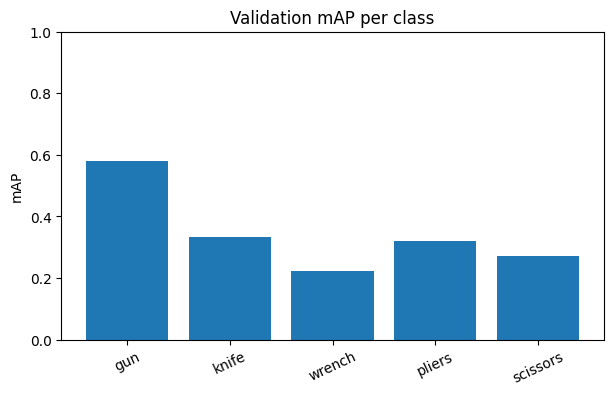

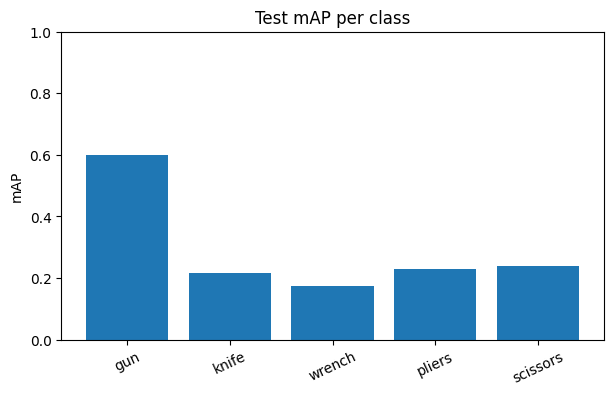

In [49]:
import matplotlib.pyplot as plt


def plot_per_class_map(metrics, title, wandb_name):
    class_maps = metrics.get("map_per_class", [])

    if not isinstance(class_maps, list):
        print("No per-class mAP to plot.")
        return

    values = []
    names = []

    for i, name in enumerate(CLASS_NAMES):
        if i < len(class_maps) and class_maps[i] >= 0:
            names.append(name)
            values.append(class_maps[i])

    if len(values) == 0:
        print("No valid per-class mAP values to plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(names, values)
    ax.set_ylim(0, 1)
    ax.set_ylabel("mAP")
    ax.set_title(title)
    plt.xticks(rotation=25)
    plt.show()

    if wandb_run is not None:
        wandb.log({wandb_name: wandb.Image(fig)})


plot_per_class_map(val_map, "Validation mAP per class", "plots/val_map_per_class")
plot_per_class_map(test_map, "Test mAP per class", "plots/test_map_per_class")

## Training curves


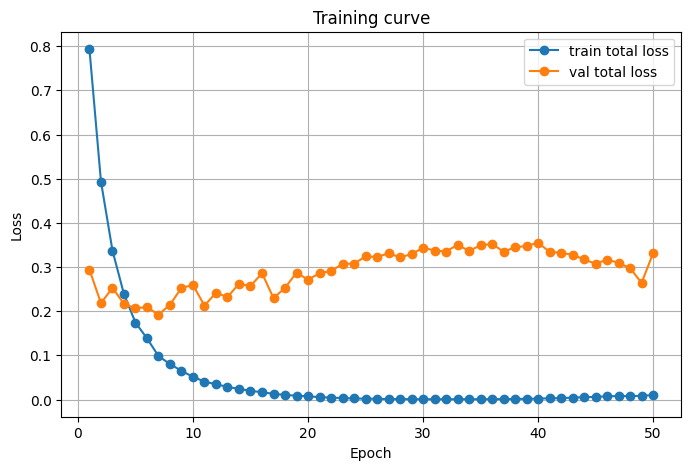

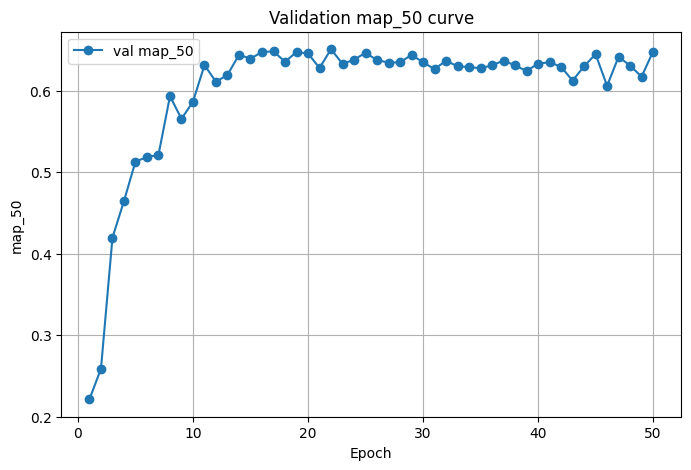

In [50]:
import matplotlib.pyplot as plt


def plot_training_history(history):
    epochs = [item["epoch"] for item in history]
    train_total = [item["train"]["total_loss"] for item in history]
    val_total = [item["val"]["total_loss"] for item in history]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(epochs, train_total, marker="o", label="train total loss")
    ax.plot(epochs, val_total, marker="o", label="val total loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training curve")
    ax.legend()
    ax.grid(True)
    plt.show()

    if wandb_run is not None:
        wandb.log({"plots/training_curve": wandb.Image(fig)})

    metric_epochs = []
    metric_values = []

    for item in history:
        val_detection = item.get("val_detection")
        if not isinstance(val_detection, dict):
            continue

        metric_value = val_detection.get(BEST_CHECKPOINT_METRIC)
        if metric_value is None:
            continue

        metric_epochs.append(item["epoch"])
        metric_values.append(metric_value)

    if len(metric_values) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(metric_epochs, metric_values, marker="o", label=f"val {BEST_CHECKPOINT_METRIC}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(BEST_CHECKPOINT_METRIC)
        ax.set_title(f"Validation {BEST_CHECKPOINT_METRIC} curve")
        ax.legend()
        ax.grid(True)
        plt.show()

        if wandb_run is not None:
            wandb.log({f"plots/val_{BEST_CHECKPOINT_METRIC}_curve": wandb.Image(fig)})


if len(history) > 0:
    plot_training_history(history)
elif HISTORY_PATH.exists():
    with open(HISTORY_PATH, "r", encoding="utf-8") as f:
        loaded_history = json.load(f)
    plot_training_history(loaded_history)
else:
    print("No history found yet.")


## Visualize decoded predictions


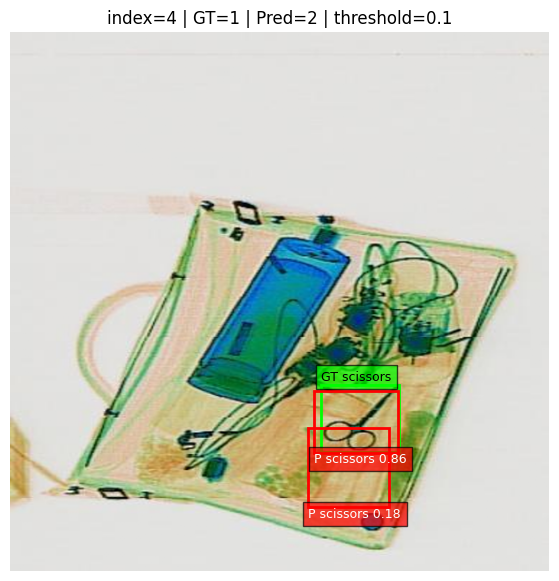

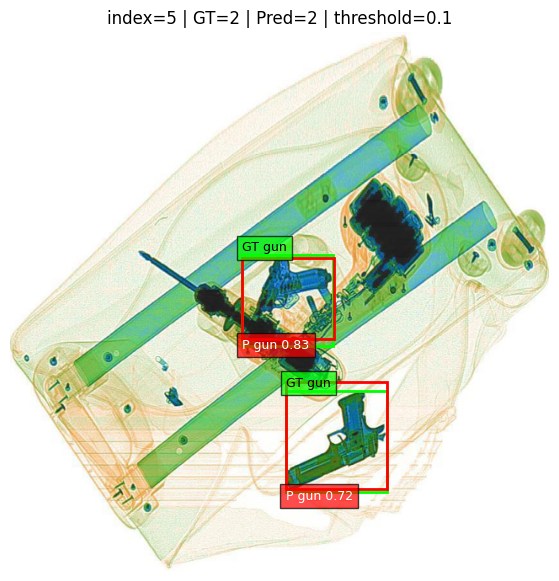

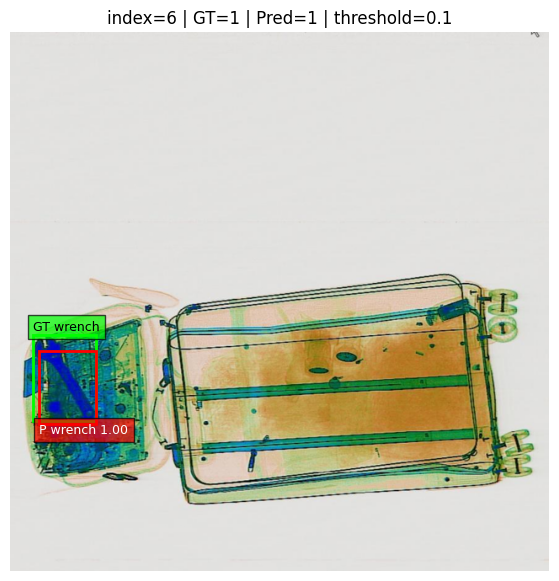

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualize_model_predictions(
    model,
    dataset,
    dataset_index,
    device,
    confidence_threshold=0.10,
    nms_iou_threshold=0.50,
    max_detections=20,
):
    model.eval()

    image, target = dataset[dataset_index]
    image_batch = image.unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(image_batch)

    decoded = decode_predictions(
        predictions,
        confidence_threshold=confidence_threshold,
        nms_iou_threshold=nms_iou_threshold,
        max_detections=max_detections,
    )[0]

    image_np = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(image_np)

    for box, label in zip(target["boxes"], target["labels"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            max(y1 - 5, 0),
            f"GT {get_class_name(label.item())}",
            fontsize=9,
            color="black",
            bbox=dict(facecolor="lime", alpha=0.7),
        )

    for box, score, label in zip(decoded["boxes"], decoded["scores"], decoded["labels"]):
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1,
            min(y2 + 12, IMAGE_SIZE),
            f"P {get_class_name(label.item())} {float(score):.2f}",
            fontsize=9,
            color="white",
            bbox=dict(facecolor="red", alpha=0.7),
        )

    ax.set_title(
        f"index={dataset_index} | GT={len(target['boxes'])} | "
        f"Pred={len(decoded['boxes'])} | threshold={confidence_threshold}"
    )
    ax.axis("off")
    plt.show()


positive_val_indices = find_first_positive_indices(val_dataset, n=3)
for idx in positive_val_indices:
    visualize_model_predictions(
        model=model,
        dataset=val_dataset,
        dataset_index=idx,
        device=device,
        confidence_threshold=0.10,
        nms_iou_threshold=0.50,
        max_detections=20,
    )

In [52]:

if wandb_run is not None:
    wandb.finish()


test_eval/map,▁
test_eval/map_50,▁
test_eval/map_75,▁
test_eval/map_gun,▁
test_eval/map_knife,▁
test_eval/map_pliers,▁
test_eval/map_scissors,▁
test_eval/map_wrench,▁
val_eval/map,▁
val_eval/map_50,▁
+6,...


We implemented a small student detector with a ResNet18 backbone. Each grid cell predicts two boxes. For each object, we assign it to the cell containing its center. The box target uses local offsets inside the cell for x and y and normalized width and height. The loss has three parts: objectness BCE, bbox Smooth L1, and class cross entropy. We save the best checkpoint using validation mAP@50 because this is the metric we care about for detection.